In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

deliveries_df = pd.read_csv('deliveries.csv')

display(deliveries_df.head())

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0.0,1.0,1.0,legbyes,0.0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0.0,1.0,1.0,wides,0.0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN


In [ ]:
powerplay_df = deliveries_df[deliveries_df['over'].between(0, 5)].copy()

powerplay_df['bowler_runs'] = powerplay_df['batsman_runs'] + powerplay_df['extra_runs'].fillna(0).apply(lambda x: x if x in [1,2,3,4,5] else 0)

powerplay_runs = powerplay_df.groupby('bowler')['total_runs'].sum().reset_index()
powerplay_runs.rename(columns={'total_runs': 'pp_total_runs'}, inplace=True)

powerplay_legal_balls = powerplay_df[~powerplay_df['extras_type'].isin(['wides', 'noballs'])]
powerplay_legal_balls_count = powerplay_legal_balls.groupby('bowler').size().reset_index(name='pp_legal_balls')

powerplay_stats = pd.merge(powerplay_runs, powerplay_legal_balls_count, on='bowler', how='left')

powerplay_stats['pp_overs'] = powerplay_stats['pp_legal_balls'] / 6

powerplay_stats['pp_economy'] = powerplay_stats['pp_total_runs'] / powerplay_stats['pp_overs']

display(powerplay_stats.sort_values(by='pp_economy').head())

,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy
307,SM Harwood,7.0,18,3.000000,2.333333
28,AJ Finch,3.0,6,1.000000,3.000000
43,Ankit Soni,3.0,6,1.000000,3.000000
106,GR Napier,3.0,6,1.000000,3.000000
223,N Rana,11.0,19,3.166667,3.473684


In [ ]:
death_over_df = deliveries_df[deliveries_df['over'].between(15, 19)].copy()

death_over_df['bowler_runs'] = death_over_df['batsman_runs'] + death_over_df['extra_runs'].fillna(0).apply(lambda x: x if x in [1,2,3,4,5] else 0)

death_over_runs = death_over_df.groupby('bowler')['total_runs'].sum().reset_index()
death_over_runs.rename(columns={'total_runs': 'do_total_runs'}, inplace=True)

death_over_legal_balls = death_over_df[~death_over_df['extras_type'].isin(['wides', 'noballs'])]
death_over_legal_balls_count = death_over_legal_balls.groupby('bowler').size().reset_index(name='do_legal_balls')

death_over_stats = pd.merge(death_over_runs, death_over_legal_balls_count, on='bowler', how='left')

death_over_stats['do_overs'] = death_over_stats['do_legal_balls'] / 6

death_over_stats['do_economy'] = death_over_stats['do_total_runs'] / death_over_stats['do_overs']

bowler_economy_stats = pd.merge(powerplay_stats, death_over_stats, on='bowler', how='inner')


qualifying_bowlers = bowler_economy_stats[(bowler_economy_stats['pp_overs'] >= 20) & (bowler_economy_stats['do_overs'] >= 20)]

display(qualifying_bowlers.head())


print("\nTop 10 most economical bowlers in Powerplay (min 20 PP overs & 20 DO overs):")
display(qualifying_bowlers.sort_values(by='pp_economy').head(10))

,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
5,A Mishra,174.0,138,23.000000,7.565217,791.0,497,82.833333,9.549296
7,A Nehra,1387.0,1093,182.166667,7.613907,794.0,527,87.833333,9.039848
9,A Nortje,240.0,180,30.000000,8.000000,221.0,150,25.000000,8.840000
10,A Singh,308.0,264,44.000000,7.000000,272.0,161,26.833333,10.136646
17,AB Agarkar,295.0,180,30.000000,9.833333,311.0,182,30.333333,10.252747



Top 10 most economical bowlers in Powerplay (min 20 PP overs & 20 DO overs):


,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
122,JC Archer,312.0,342,57.000000,5.473684,535.0,341,56.833333,9.413490
48,B Kumar,1564.0,1523,253.833333,6.161523,1555.0,1010,168.333333,9.237624
94,DW Steyn,1229.0,1140,190.000000,6.468421,895.0,634,105.666667,8.470032
278,SP Narine,834.0,768,128.000000,6.515625,1115.0,853,142.166667,7.842907
178,M Muralitharan,161.0,148,24.666667,6.527027,380.0,275,45.833333,8.290909
271,SL Malinga,1210.0,1111,185.166667,6.534653,1526.0,1117,186.166667,8.196956
88,DP Nannes,377.0,342,57.000000,6.614035,313.0,208,34.666667,9.028846
224,R Ashwin,1063.0,964,160.666667,6.616183,616.0,470,78.333333,7.863830
130,JJ Bumrah,868.0,772,128.666667,6.746114,1444.0,988,164.666667,8.769231
238,RJ Harris,480.0,426,71.000000,6.760563,434.0,274,45.666667,9.503650


In [ ]:
death_over_df = deliveries_df[deliveries_df['over'].between(15, 19)].copy()

death_over_df['bowler_runs'] = death_over_df['batsman_runs'] + death_over_df['extra_runs'].fillna(0).apply(lambda x: x if x in [1,2,3,4,5] else 0)

death_over_runs = death_over_df.groupby('bowler')['total_runs'].sum().reset_index()
death_over_runs.rename(columns={'total_runs': 'do_total_runs'}, inplace=True)

death_over_legal_balls = death_over_df[~death_over_df['extras_type'].isin(['wides', 'noballs'])]
death_over_legal_balls_count = death_over_legal_balls.groupby('bowler').size().reset_index(name='do_legal_balls')

death_over_stats = pd.merge(death_over_runs, death_over_legal_balls_count, on='bowler', how='left')

death_over_stats['do_overs'] = death_over_stats['do_legal_balls'] / 6

death_over_stats['do_economy'] = death_over_stats['do_total_runs'] / death_over_stats['do_overs']

display(death_over_stats.sort_values(by='do_economy').head())

,bowler,do_total_runs,do_legal_balls,do_overs,do_economy
20,AC Gilchrist,0.0,1,0.166667,0.0
48,Av,0.0,1,0.166667,0.0
92,DJ Muthuswami,1.0,6,1.000000,1.0
301,SE Rutherford,2.0,5,0.833333,2.4
288,S Rana,2.0,4,0.666667,3.0


In [ ]:

bowler_economy_stats = pd.merge(powerplay_stats, death_over_stats, on='bowler', how='inner')


qualifying_bowlers = bowler_economy_stats[(bowler_economy_stats['pp_overs'] >= 20) & (bowler_economy_stats['do_overs'] >= 20)]

display(qualifying_bowlers.head())


print("\nTop 10 most economical bowlers in Powerplay (min 20 PP overs & 20 DO overs):")
display(qualifying_bowlers.sort_values(by='pp_economy').head(10))


,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
5,A Mishra,499.0,438,73.000000,6.835616,446.0,269,44.833333,9.947955
7,A Nehra,1223.0,949,158.166667,7.732350,633.0,419,69.833333,9.064439
9,A Nortje,221.0,162,27.000000,8.185185,177.0,126,21.000000,8.428571
10,A Singh,294.0,246,41.000000,7.170732,256.0,149,24.833333,10.308725
17,AB Agarkar,349.0,234,39.000000,8.948718,266.0,158,26.333333,10.101266



Top 10 most economical bowlers in Powerplay (min 20 PP overs & 20 DO overs):


,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
87,DP Nannes,207.0,216,36.000000,5.750000,267.0,184,30.666667,8.706522
120,JC Archer,279.0,282,47.000000,5.936170,468.0,293,48.833333,9.583618
175,M Muralitharan,260.0,258,43.000000,6.046512,226.0,155,25.833333,8.748387
274,SP Narine,893.0,870,145.000000,6.158621,899.0,655,109.166667,8.235115
220,R Ashwin,1110.0,1018,169.666667,6.542240,369.0,260,43.333333,8.515385
200,Mustafizur Rahman,257.0,234,39.000000,6.589744,420.0,271,45.166667,9.298893
128,JJ Bumrah,849.0,768,128.000000,6.632812,1317.0,880,146.666667,8.979545
44,Azhar Mahmood,180.0,162,27.000000,6.666667,284.0,171,28.500000,9.964912
242,Rashid Khan,275.0,246,41.000000,6.707317,211.0,168,28.000000,7.535714
46,B Kumar,1151.0,1025,170.833333,6.737561,1363.0,854,142.333333,9.576112


/tmp/ipykernel_6817/1182445754.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


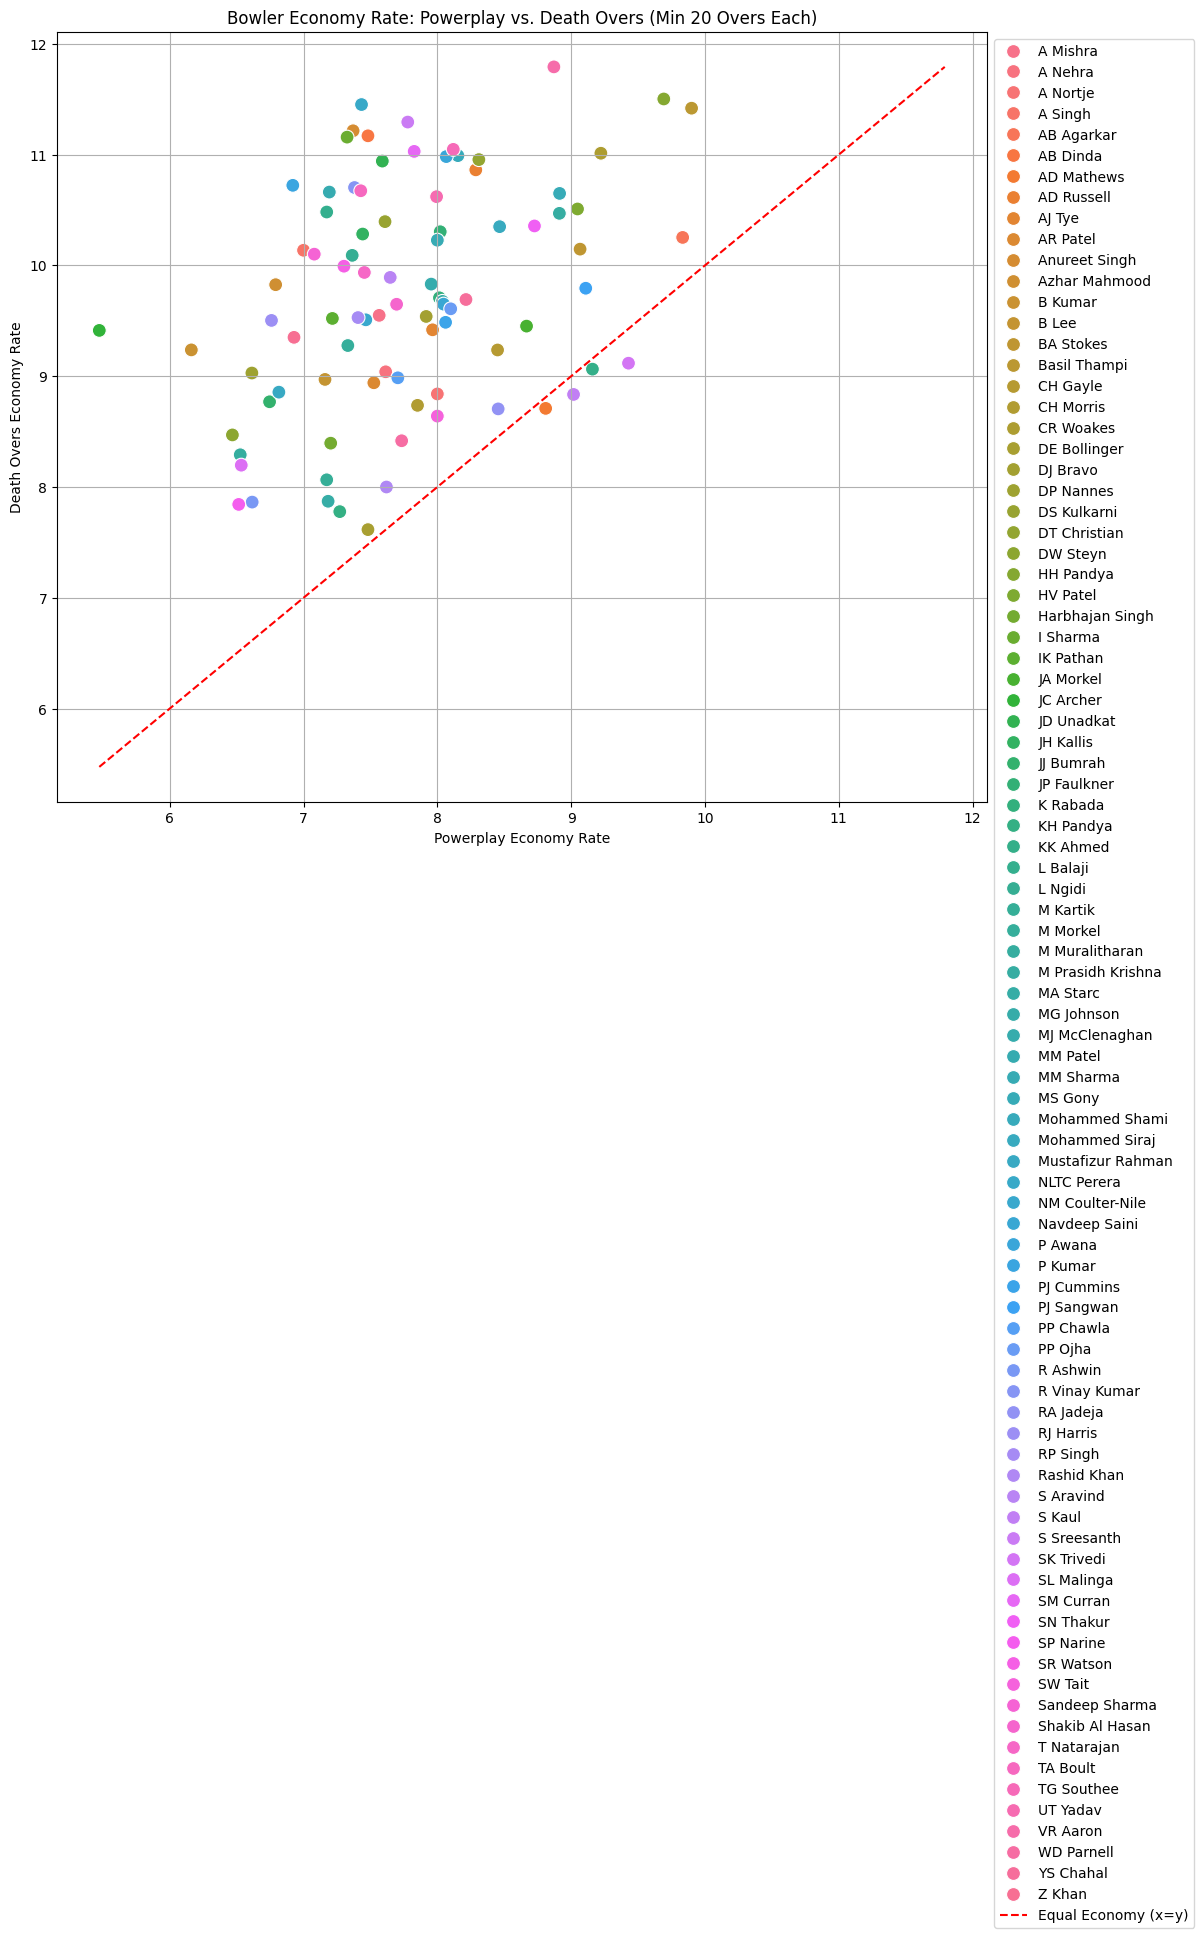

In [ ]:
plt.figure(figsize=(12, 10))
sns.scatterplot(data=qualifying_bowlers, x='pp_economy', y='do_economy', hue='bowler', s=100)

max_economy = max(qualifying_bowlers['pp_economy'].max(), qualifying_bowlers['do_economy'].max())
min_economy = min(qualifying_bowlers['pp_economy'].min(), qualifying_bowlers['do_economy'].min())
plt.plot([min_economy, max_economy], [min_economy, max_economy], 'r--', label='Equal Economy (x=y)')

plt.title('Bowler Economy Rate: Powerplay vs. Death Overs (Min 20 Overs Each)')
plt.xlabel('Powerplay Economy Rate')
plt.ylabel('Death Overs Economy Rate')
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()